# CODING PROBLEM - WEEK 2

The problem is basically based on week 1's problem, where we defined a star field and then did some photometry analysis. 

Now, in addition to this, we now have to define a automated way to find stars in a star field/ FITS image.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Simulating the Star Field
In observational astronomy, a star's light spreads across the camera sensor, forming a **Point Spread Function (PSF)**. To simulate this, we use a 2D Gaussian profile.

The image generation logic below includes:
* A background bias (average night sky glow) and random Gaussian noise.
* Two distinct stars modeled with exponential decay based on their distance from a center peak.

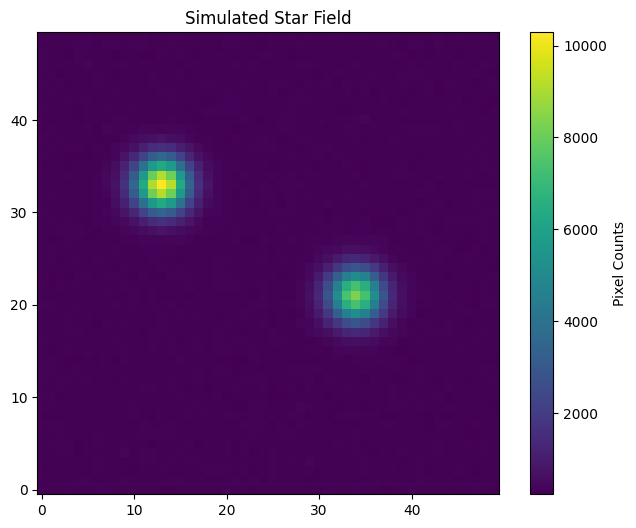

In [ ]:
def generate_image():
    np.random.seed(42)
    # Base background noise
    image = np.random.normal(loc=300, scale=20, size=(50, 50))
    y, x = np.mgrid[0:50, 0:50]
    
    # Star 1 (Bright) at X=13, Y=33
    image += 10000 * np.exp(-((x - 13)**2 + (y - 33)**2) / 8)
    
    # Star 2 (Dimmer) at X=34, Y=21
    image += 8000 * np.exp(-((x - 34)**2 + (y - 21)**2) / 8)
    
    return image

image = generate_image()

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap='viridis', origin='lower')
plt.colorbar(label='Pixel Counts')
plt.title('Simulated Star Field')
plt.show()

## 2. Automating Detection

This function implements a search algorithm to locate the brightest points in an image. It identifies the coordinates of peak intensity values while preventing duplicate detections of the same star's surrounding halo by enforcing a physical proximity threshold.

---

* **`sorted_flat_indices = np.argsort(image.ravel())[::-1]`**
    Performs three operations sequentially: `image.ravel()` flattens the 2D array into a 1D list, `np.argsort()` sorts those indices from lowest to highest pixel value, and `[::-1]` reverses the array so the absolute brightest pixel indices are placed at the very front.
* **`y, x = np.unravel_index(flat_index, image.shape)`**
    Translates the 1D flat index back into the 2D row and column coordinates, representing the pixel's actual spatial location on the image grid.
* **`too_close = True`**
* **`break`**
    This loop checks the distance from the current candidate star (x, y) to all previously detected stars in star_centers. If the squared distance is less than the squared minimum distance, it sets too_close to True and breaks out of the loop.
---

#### Points to be noted

* This implementation acts strictly as an absolute peak-finder rather than calculating the true weighted centroid of the star's light profile.


In [13]:
def find_stars(image, num_stars, min_distance):
    sorted_flat_indices = np.argsort(image.ravel())[::-1] 
    star_centers = []
    
    for flat_index in sorted_flat_indices:
        y, x = np.unravel_index(flat_index, image.shape)

        too_close = False 
    
        for (star_x, star_y) in star_centers:
            if (x - star_x)**2 + (y - star_y)**2 < (min_distance**2):
                too_close = True
                break
            
        if not too_close:
            star_centers.append((x, y))  # Stores as (x, y)
                        
        if len(star_centers) == num_stars:
            break
            
    return star_centers


detected_stars = find_stars(image, num_stars=2, min_distance=10)

## 3. Determining Aperture and Annulus Size

### The FWHM Method for Aperture Size
To calculate the ideal aperture radius, we evaluate the **Full Width at Half Maximum (FWHM)** of our simulated Gaussian function: $f(r) = \exp(-r^2 / 8)$.
* Comparing this to the standard Gaussian $f(r) = \exp(-r^2 / 2\sigma^2)$, we find $\sigma = 2$.
* The standard conversion is $\text{FWHM} \approx 2.355 \times \sigma$, yielding $\approx 4.71 \text{ pixels}$.
* Setting our aperture radius to roughly $1 \times \text{FWHM}$ gives an optimal integer radius of **5 pixels** (a squared distance of 25). 

We will use an inner annulus radius of 8 and an outer radius of 12 for background sky measurement.


## 4. Magnitude
Say we have two stars, with flux $f_1$ and $f_2$. We can define the magnitude difference between the stars as:

$$m_1 - m_2 = -2.5\log_{10}(f_1/f_2)$$

Clearly, if the flux ratio is 100, the magnitude difference is 5. This equation is the fundamental equation needed to define and deal with magnitudes.

In [ ]:
y_grid, x_grid = np.mgrid[0:image.shape[0], 0:image.shape[1]]
net_fluxes = []

print("--- Detected Stars & Net Flux ---")

for i, (x_c, y_c) in enumerate(detected_stars):
    # Calculate squared distance from this star's center
    distance_sq = (x_grid - x_c)**2 + (y_grid - y_c)**2
    
    # Aperture (Radius 5 -> distance_sq <= 25)
    aperture_area = distance_sq <= 25
    aperture_pixels_list = image[aperture_area]
    total_aperture_flux = np.sum(aperture_pixels_list)
    number_of_aperture_pixels = len(aperture_pixels_list)
    
    # Annulus (Radius 8 to 12 -> distance_sq > 64 and <= 144)
    annulus_area = (distance_sq > 64) & (distance_sq <= 144)
    annulus_pixels_list = image[annulus_area]
    background_noise = np.median(annulus_pixels_list)
    
    # Net Flux
    net_star_flux = total_aperture_flux - (background_noise * number_of_aperture_pixels)
    net_fluxes.append(net_star_flux)
    
    print(f"Star {i+1} at (X={x_c}, Y={y_c}):")
    print(f"  Net Flux: {net_star_flux:.2f}")


net_star_flux_1 = net_fluxes[0]
net_star_flux_2 = net_fluxes[1]
    
delta_m_12 = -2.5 * np.log10(net_star_flux_1 / net_star_flux_2)

print(f"\n--- Relative Magnitude ---")
print(f"Magnitude Difference (Delta m): {delta_m_12:.4f}")

--- Detected Stars & Net Flux ---
Star 1 at (X=13, Y=33):
  Net Flux: 241016.39
Star 2 at (X=34, Y=21):
  Net Flux: 192990.33

--- Relative Magnitude ---
Magnitude Difference (Delta m): -0.2413
